## 세상에 없는 얼굴 GAN, 오토인코더
### 3. 적대적 신경망 실행하기, GAN 모델 만들기

In [15]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation, LeakyReLU, UpSampling2D, Conv2D
from tensorflow.keras.models import Sequential, Model

import numpy as np
import matplotlib.pyplot as plt

#생성자 모델을 만듭니다. 가짜 이미지 만들기 (아무 의미 없는 무작위 노이즈에서 숫자의 형태 만들기)
generator = Sequential()
generator.add(Dense(128*7*7, input_dim=100, activation=LeakyReLU(0.2)))
generator.add(BatchNormalization())
generator.add(Reshape((7,7,128)))
generator.add(UpSampling2D()) #크기를 두 배로 키우는 함수 
generator.add(Conv2D(64, kernel_size=5, padding='same'))
generator.add(BatchNormalization())
generator.add(Activation(LeakyReLU(0.2)))
generator.add(UpSampling2D())
generator.add(Conv2D(1, kernel_size=5, padding='same', activation='tanh'))


#판별자 모델을 만듭니다. (들어온 이미지가 실제 데이터인지 생성자가 만든 가짜인지 판단)
discriminator = Sequential()
discriminator.add(Conv2D(64, kernel_size=5, strides=2, padding='same', input_shape=(28,28,1)))
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3)) #과적합 방지
discriminator.add(Conv2D(128, kernel_size=5, strides=2, padding='same'))
discriminator.add(Activation(LeakyReLU(0.2)))
discriminator.add(Dropout(0.3))
discriminator.add(Flatten())
discriminator.add(Dense(1, activation='sigmoid'))
discriminator.compile(loss='binary_crossentropy', optimizer='adam')
discriminator.trainable = False #GAN 전체를 학습시킬 때는 판별자만 따로 훈련되지 않게 고정 

#생성자와 판별자 모델을 연결시키는 gan모델을 만듦
#생성자가 만든 결과물(generator(ginput))을 판별자(discriminator)에 입력하여 가짜 이미지인지 판단
ginput = Input(shape=(100,)) #노이즈 입력층
dis_output = discriminator(generator(ginput))
gan = Model(ginput, dis_output)
gan.compile(loss='binary_crossentropy', optimizer='adam')
gan.summary()




    

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 28, 28, 1)      │       865,281 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,078,146 (4.11 MB)

 Trainable params: 852,609 (3.25 MB)

 Non-trainable params: 225,537 (881.00 KB)

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 d_loss:0.6993 g_loss:0.6978
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Epoch 100 d_loss:0.7711 g_loss:0.5273
Epoch 200 d_loss:0.8408 g_loss:0.4506
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Epoch 300 d_loss:0.9003 g_loss:0.4025
Epoch 400 d_loss:0.9471 g_loss:0.3685
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Epoch 500 d_loss:0.9831 g_loss:0.3432
Epoch 600 d_loss:1.0110 g_loss:0.3238
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Epoch 700 d_loss:1.0338 g_loss:0.3086
Epoch 800 d_loss:1.0527 g_loss:0.2962
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Epoch 900 d_loss:1.0690 g_loss:0.2859
Epoch 1000 d_loss:1.0829 g_loss:0.2773
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Epoch 1100 d_loss:1.0948 g_loss:0.2700
Epoch 1200 d_loss:1.1051 g_loss:0.2638
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Epoch 1300 d_loss:1.1138 g_loss:0.2585
Epoch 1400 d_loss:1.1214 g_loss:0.2538
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Epoch 1500 d_loss:1.1281 g_loss:0.2498
Epoch 1600 d_loss:1.1340 g_loss:0.2463
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Epoch 

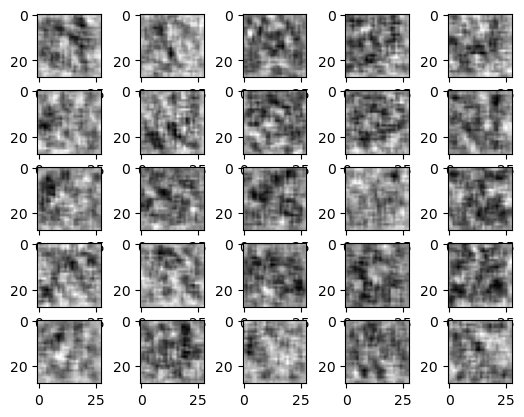

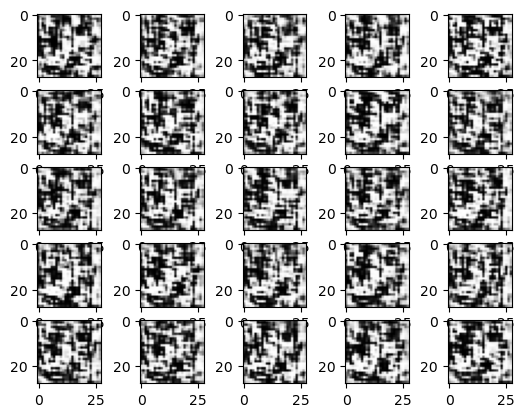

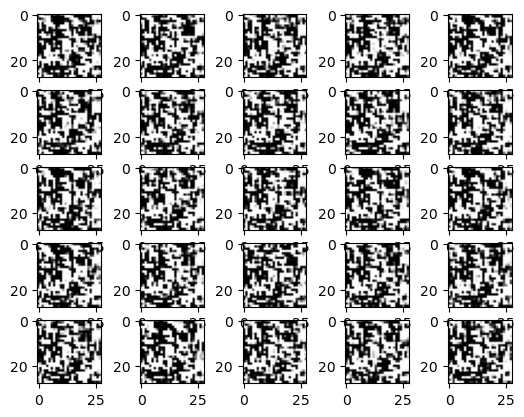

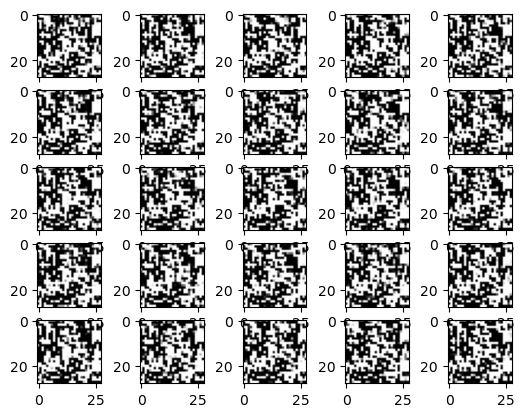

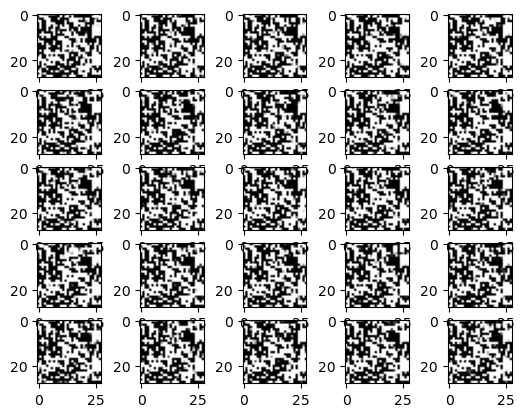

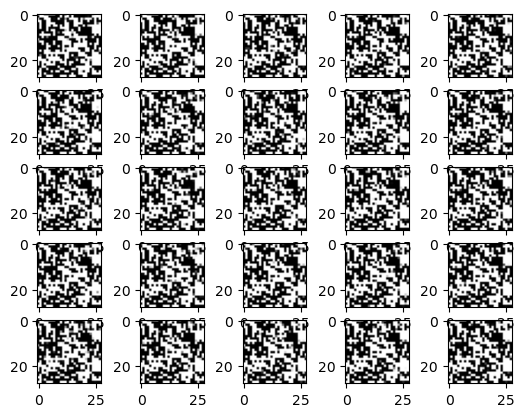

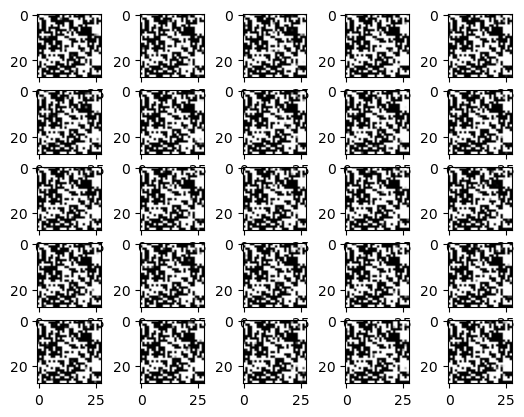

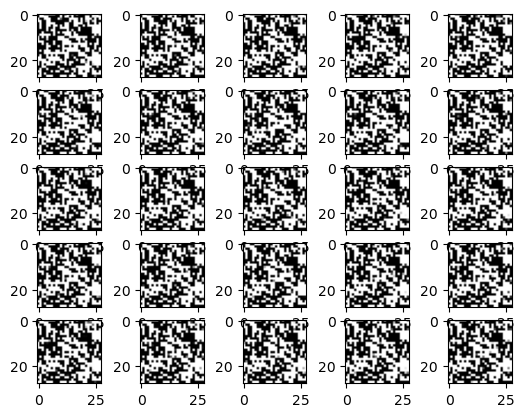

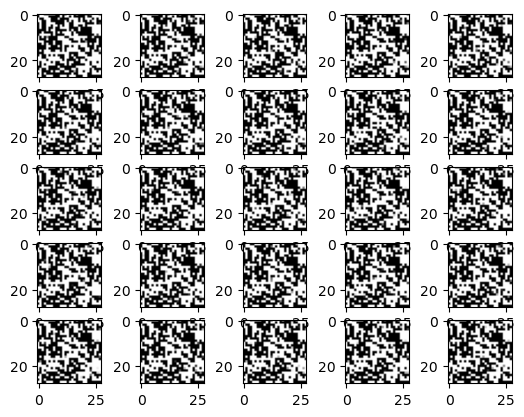

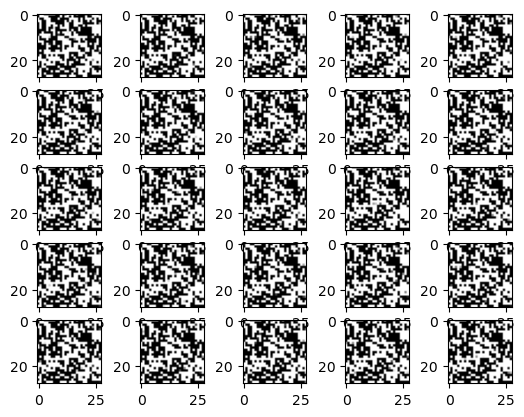

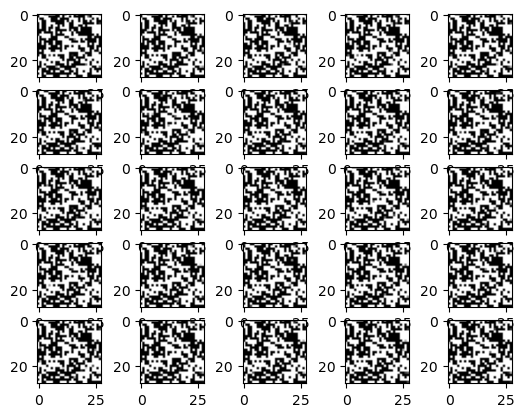

In [16]:
#신경망을 실행시키는 함수를 만듭니다. 
def gan_train(epoch, batch_size, save_interval):

    #MNIST 데이터를 불러옵니다.

    (X_train, _), (_, _) = mnist.load_data()

    #데이터를 정규화합니다.
    X_train = X_train.reshape(X_train.shape[0], 28,28,1).astype('float32')
    X_train = (X_train - 127.5) / 127.5

    #학습에 쓸 정답 레이블(진짜=1, 가짜=0)준비
    true = np.ones((batch_size, 1))
    fake = np.zeros((batch_size, 1))

    for i in range(epoch):
        #실제 데이터를 판별자에 입력하는 부분
        #1. 판별자 학습: 실제 데이터 입력
        idx = np.random.randint(0, X_train.shape[0], batch_size)
        images = X_train[idx]
        d_loss_real = discriminator.train_on_batch(images,true)

        #2. 판별자 학습: 가짜 데이터 입력
        noise = np.random.normal(0, 1, (batch_size, 100))
        gen_images = generator.predict(noise, verbose=0)
        d_loss_fake = discriminator.train_on_batch(gen_images, fake)
        
        #판별자의 전체 오차를 계산
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        #3. 생성자 학습(GAN 모델 이용)
        g_loss = gan.train_on_batch(noise, true)

        #4. 학습 결과 출력
        if i % 100 == 0:
            print("Epoch %d" % i, 'd_loss:%.4f'%d_loss, 'g_loss:%.4f'%g_loss)

        #중간 과정을 이미지로 저장해 주는 부분으로 만들어진 이미지는 gan_images 폴더에 저장됨
        if i % save_interval == 0:
            noise = np.random.normal(0, 1, (25, 100))
            gen_image = generator.predict(noise)
            gen_image = 0.5 * gen_image + 0.5

            fig,axs = plt.subplots(5,5)
            count =0
            for j in range(5):
                for k in range(5):
                    axs[j, k].imshow(gen_image[count, :,:,0], cmap='gray')
                    count +=1
            fig.savefig('./gan_mnist_%d.png' % i)

gan_train(2001, 32, 200)


## 4. 이미지의 특징을 추출하는 오토인코더

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Reshape, Flatten

import matplotlib.pyplot as plt
import numpy as np
#1. 데이터 불러오기 + 전처리
(X_train, _), (X_test, _) = mnist.load_data() #훈련용 이미지 X_train만 쓰고, 나머지는 버리기
#훈련 이미지  #테스트 이미지
X_train = X_train.reshape(X_train.shape[0], 28,28,1).astype('float32') /255
X_test = X_test.reshape(X_test.shape[0], 28,28,1).astype('float32') /255

In [ ]:
#2. 오토인코더 모델 만들기
# 입력 이미지 = 출력 이미지가 되어야 학습이 가능하기 때문에 크기가 맞도록 대칭구조로 설정
autoencoder = Sequential()


#인코딩 부분입니다. (인코더: 이미지를 압축해서 핵심만 남김)
autoencoder.add(Conv2D(16,kernel_size=3, padding='same', input_shape=(28,28,1), activation='relu'))
#3x3 필터를 16개 사용해서 이미지에서 기본 특징을 뽑음 
#padding='same'은 이미지의 크기(28x28)를 유지하기 위해 사용
#출력 shape: (28,28,16=kernel 수=채널 수) = 28x28크기의 특징 맵이 16장 있다
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
#padding='same'은 크기를 줄이되, 나중에 정확히 복원할 수 있도록 출력 크기를 예측 가능하게 유지하기 위한 옵션
#2x2 영역에서 큰 값만 남겨서 크기를 절반으로 줄임 
#출력 shape: (14,14,16) 
#MaxPooling은 채널(특징 맵)개수는 그대로 유지하고 공간 크기만 줄임
autoencoder.add(Conv2D(8,kernel_size=3, padding='same', activation='relu'))
#14x14 크기의 특징 맵에서 8개의 필터를 사용하여 특징을 추출
#크기는 유지
#출력 shape: (14,14,8)
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
#다시 절반 축소 (7,7,8)
#Pooling은 정보를 줄이기만 하고 어떤 정보가 중요한지는 정리해주지 않으므로 Conv2D로 정보를 재정렬 해줘야함
autoencoder.add(Conv2D(8,kernel_size=3, padding='same', activation='relu'))
#크기 유지하고 7x7x8상태에서 특징을 한 번 더 정리 
#정리 layer

#디코딩 부분입니다. (디코더: 압축된 걸 다시 원래처럼 복원)
autoencoder.add(Conv2D(8,kernel_size=3, padding='same', activation='relu'))
autoencoder.add(UpSampling2D())
#출력 shape: (14,14,8)
autoencoder.add(Conv2D(16,kernel_size=3, padding='same', activation='relu'))
#출력 shape: (14,14,16)
autoencoder.add(UpSampling2D())
#출력 shape: (28,28,16)
autoencoder.add(Conv2D(1,kernel_size=3, padding='same', activation='sigmoid'))
#최종 출력 이미지를 위해 채널을 1로 줄임(흑백)
#출력 shape:(28,28,1)

#전체 구조 확인
autoencoder.summary()

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_55 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_24 (UpSampling2D) │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_25 (UpSampling2D) │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,801 (14.85 KB)

 Trainable params: 3,801 (14.85 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
autoencoder.output_shape

(None, 28, 28, 1)

In [29]:
#컴파일 및 학습
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(X_train, X_train, epochs=50, batch_size=128, validation_data=(X_test, X_test))

#학습 결과 출력 
random_test = np.random.randint(X_test.shape[0], size=5)
ae_imgs = autoencoder.predict(X_test)



Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1598 - val_loss: 0.0910
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0870 - val_loss: 0.0828
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0820 - val_loss: 0.0797
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0796 - val_loss: 0.0779
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0781 - val_loss: 0.0769
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0770 - val_loss: 0.0758
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0761 - val_loss: 0.0750
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0754 - val_loss: 0.0743
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0747 - val_loss: 0.0737
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0741 - val_loss: 0.0733
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0737 - val_loss: 0.0729
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

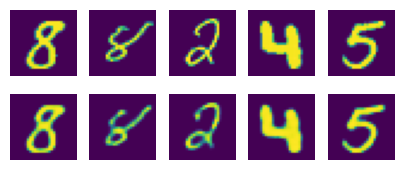

In [30]:
plt.figure(figsize=(7,2))

for i, image_idx in enumerate(random_test):
    ax = plt.subplot(2,7,i+1)
    plt.imshow(X_test[image_idx].reshape(28,28))
    ax.axis('off')
    ax=plt.subplot(2,7,7+i+1)
    plt.imshow(ae_imgs[image_idx].reshape(28,28))
    ax.axis('off')
plt.show()